# Strength-matched MTS across nine observation sizes

Parent-grouped class accuracy: mean covariance **16.7%**, MPI means **98.5%**, distributions **99.6%**, and training-complete SPI–SPI **100.0%**; chance is **16.7%**. The strongest full-mean comparison scores **100.0%**.

This is an exploratory extension to $M\in\{8,16,32\}$ and $T\in\{100,500,1000\}$, with five instances of each class in every cell. Six matched classes give 270 observations: VAR, Wave, CML, Kuramoto, correlated Gaussian and correlated Cauchy. Independent Gaussian/Cauchy add 90 separate controls. No class, point or embedding seed is selected for favorable separation.

**Five parents, not 45 independent recordings per class.** Each class has five independent 32-channel, 1,000-observation parents. Centered contiguous channel windows and initial time prefixes give the nine nested views. Validation leaves out an entire parent-instance block, including all nine sizes and all classes. This prevents overlapping observations from appearing in both training and evaluation. Five independent blocks support an exploratory comparison, not precise per-cell or population-performance claims.

The preceding single-size held experiment obtained 16.7% covariance-mean accuracy and 100% for MPI means, distributions and SPI–SPI. Thus matching scalar strength did **not** remove information from all MPI means. This extension tests observation-size robustness; it is not assumed to solve the stronger marginal-matching problem.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd().resolve()
while not (ROOT/'pyproject.toml').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
RUN='pearson-size-matched-261004'; OUT=ROOT/'results/representation'/RUN
metrics=pd.read_csv(OUT/'metrics.csv')
display(metrics.round(3))

,method,n,independent_parent_blocks,BA,parent_min,parent_max,chance
0,mean,270,5,0.985,0.963,1.000,0.167
1,distribution,270,5,0.996,0.981,1.000,0.167
2,z,270,5,1.000,1.000,1.000,0.167
3,z_validity,270,5,0.433,0.389,0.481,0.167
4,b,270,5,0.167,0.167,0.167,0.167
5,pearson_two,270,5,0.167,0.167,0.167,0.167
6,z_complete,270,5,1.000,1.000,1.000,0.167
7,z_standard,270,5,0.970,0.926,1.000,0.167
8,mean_complete,270,5,0.985,0.963,1.000,0.167
9,z_shuffled_complete,270,5,0.167,0.130,0.204,0.167


## Generator and matching rule

Native parents use a 32-node VAR with self coefficient .7 and .1 per ring neighbor; a periodic wave with speed $10\sqrt{.2/.08}$ and fixed time step .00125; an observed 32-channel window of a 100-site CML with $\alpha=1.895$, $\epsilon=.109375$; and a 32-oscillator Kuramoto model with $K=-50$, step .00625 and mean intrinsic frequency 3, observing sine of phase. The CML and Kuramoto settings are medians of the preceding development calibrations, not selected using this experiment's SPI outcomes. Observation-size changes therefore do not change the parent dynamics. Noise variants use heterogeneous shared-input loadings; independent controls preserve the paired independent innovations.

All channels are centered and standardized to unit empirical variance. Both $b=\operatorname{mean}_{i\ne j}\widehat{\operatorname{Cov}}(x_i,x_j)$ and $a=\operatorname{mean}_{i\ne j}|r_{ij}|$ are matched within each size/parent block. At $T=100$, chance sample correlations are larger, so enforcing the old absolute target .07 through independent observation noise is not generally feasible. Instead the common absolute target is the midpoint between the largest sampled innovation-correlation floor and the smallest coupled-signal absolute correlation in that block. It uses covariance only, never other SPI outcomes.

The signed target is $b=a(S_M^2-M)/[M(M-1)]$, where $S_M=2\operatorname{round}(\sqrt{2M}/2)$. This follows from an equicorrelated reference after channel polarity changes with sign sum $S_M$: it gives a motivated feasible sign–magnitude ratio, rather than an arbitrary tiny signed mean. Targets vary across observation sizes, but their **pooled distributions are identical across the balanced classes**.

Rotate two fixed independent innovation arrays as $E_\theta=\cos\theta E_1+\sin\theta E_2$. For the four dynamical families, tune Gaussian measurement-noise amplitude to the absolute target; for Gaussian/Cauchy variants, tune common-input mixing using innovations of the corresponding family. A bounded search over channel polarities and a continuous root in $\theta$ then match signed mean while retaining the absolute target. No covariance whitening or post-computation MPI adjustment is applied. The noise amplitude and orientation are data-conditioned, so this is an engineered observation-space control, not universal physical/causal coupling equality. Cauchy covariance statements are finite-sample only.

A simpler signed-mean-only feasibility construction was rejected before any SPI job because it matched mainly through positive–negative cancellation while absolute correlations remained strongly different. Its inputs remain preserved as `pearson-size-control-261004`.

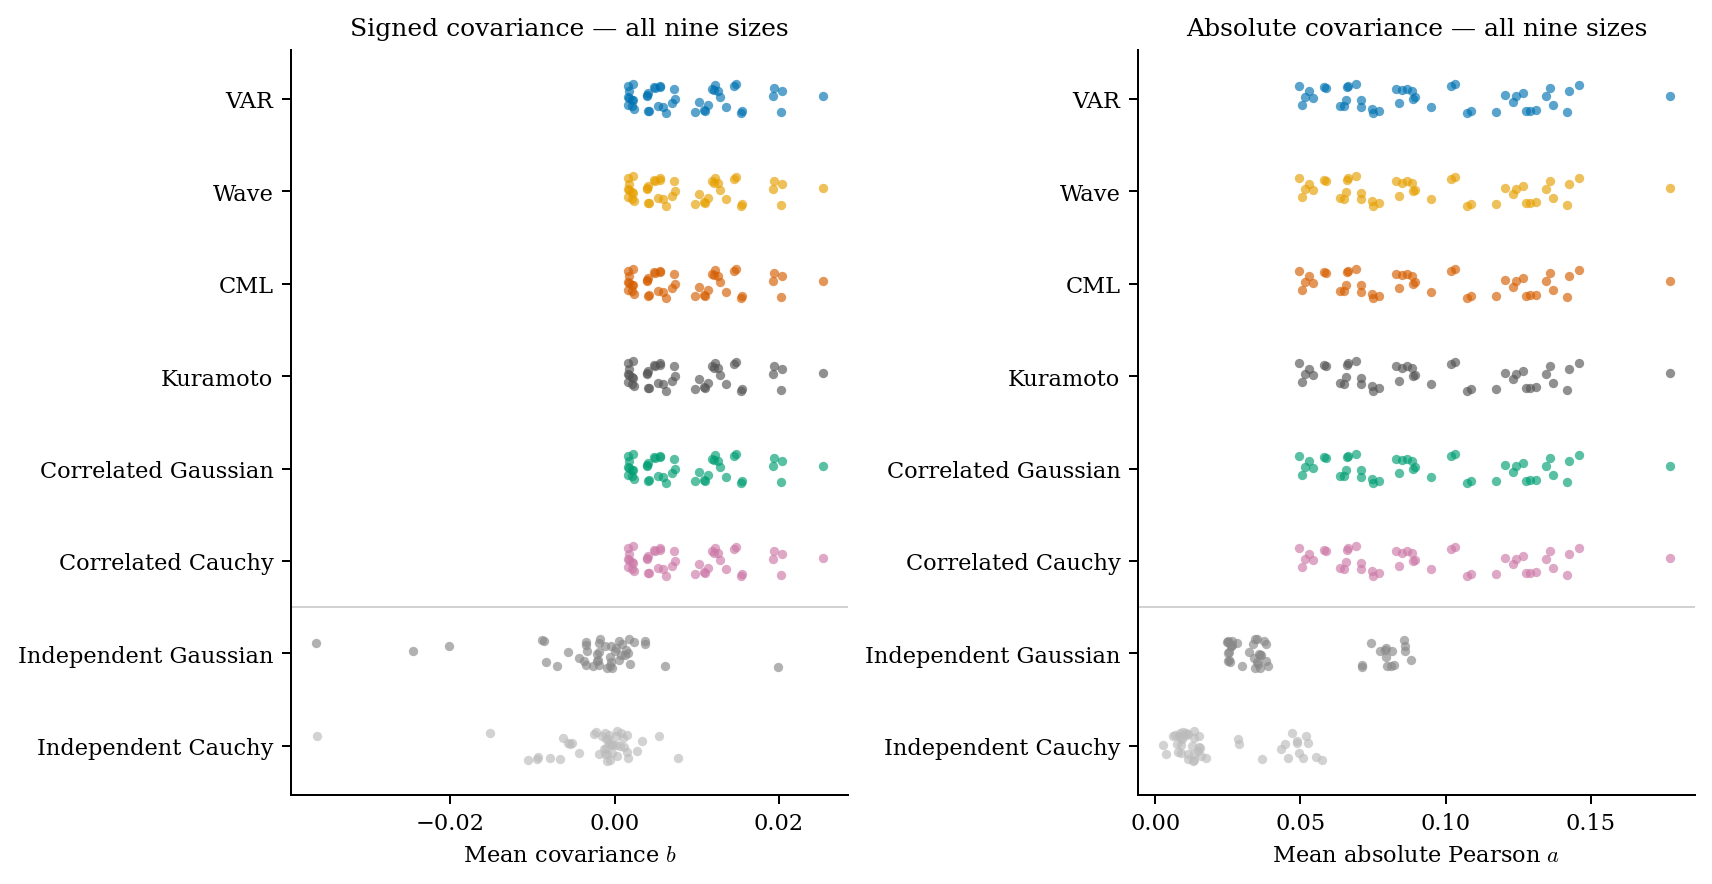

target_absolute         target_signed        
                    min     max           min     max
M  T                                                 
8  100           0.1346  0.1772        0.0192  0.0253
   500           0.0828  0.1087        0.0118  0.0155
   1000          0.0771  0.0948        0.0110  0.0135
16 100           0.1174  0.1460        0.0098  0.0122
   500           0.0708  0.0888        0.0059  0.0074
   1000          0.0580  0.0664        0.0048  0.0055
32 100           0.1206  0.1291        0.0039  0.0042
   500           0.0651  0.0748        0.0021  0.0024
   1000          0.0495  0.0545        0.0016  0.0018

In [2]:
display(Image(filename=str(OUT/'figures/matched-strength.png')))
targets=pd.read_csv(OUT/'targets.csv')
display(targets.groupby(['M','T'])[['target_absolute','target_signed']].agg(['min','max']).round(4))

## Baseline hierarchy and fixed geometry

The hierarchy is mean covariance $b$, the vector of MPI means from the 289-SPI p90 subset $m$, seven marginal summaries per MPI (mean, SD, 10/25/50/75/90 percentiles), and signed Pearson SPI–SPI $z$ over aligned ordered off-diagonal entries. Means/distributions use training-only SD scaling, clipping at five SD and PCA20. Primary $z$ uses training-complete features, centering and PCA20, with no per-feature rescaling. Logistic regression fixes $C=1$. Full-mean linear/RBF/tree classifiers, standardized $z$, validity-only and independently edge-shuffled $z$ remain visible as controls. Shuffling preserves MPI marginal values while disrupting their alignment; this need not represent a realizable MTS.

Every validation fold refits all feature selection and preprocessing using only the other four parent blocks. Pooled and per-cell class accuracies below are predictions for excluded parents. Parent minimum/maximum are descriptive variability, not confidence intervals. Only five parents contribute to each cell.

**The plots are descriptive all-data fits**, separately from validation: PCA20 then PCA2 or UMAP with 30 neighbors, minimum distance .1 and seed 261003, using all 270 matched observations. Colors denote class, marker shapes denote $M$, and marker size increases with $T$. No classifier score is computed from this all-data fit. Overlap or clustering in two dimensions is not a test of information absence or superiority.

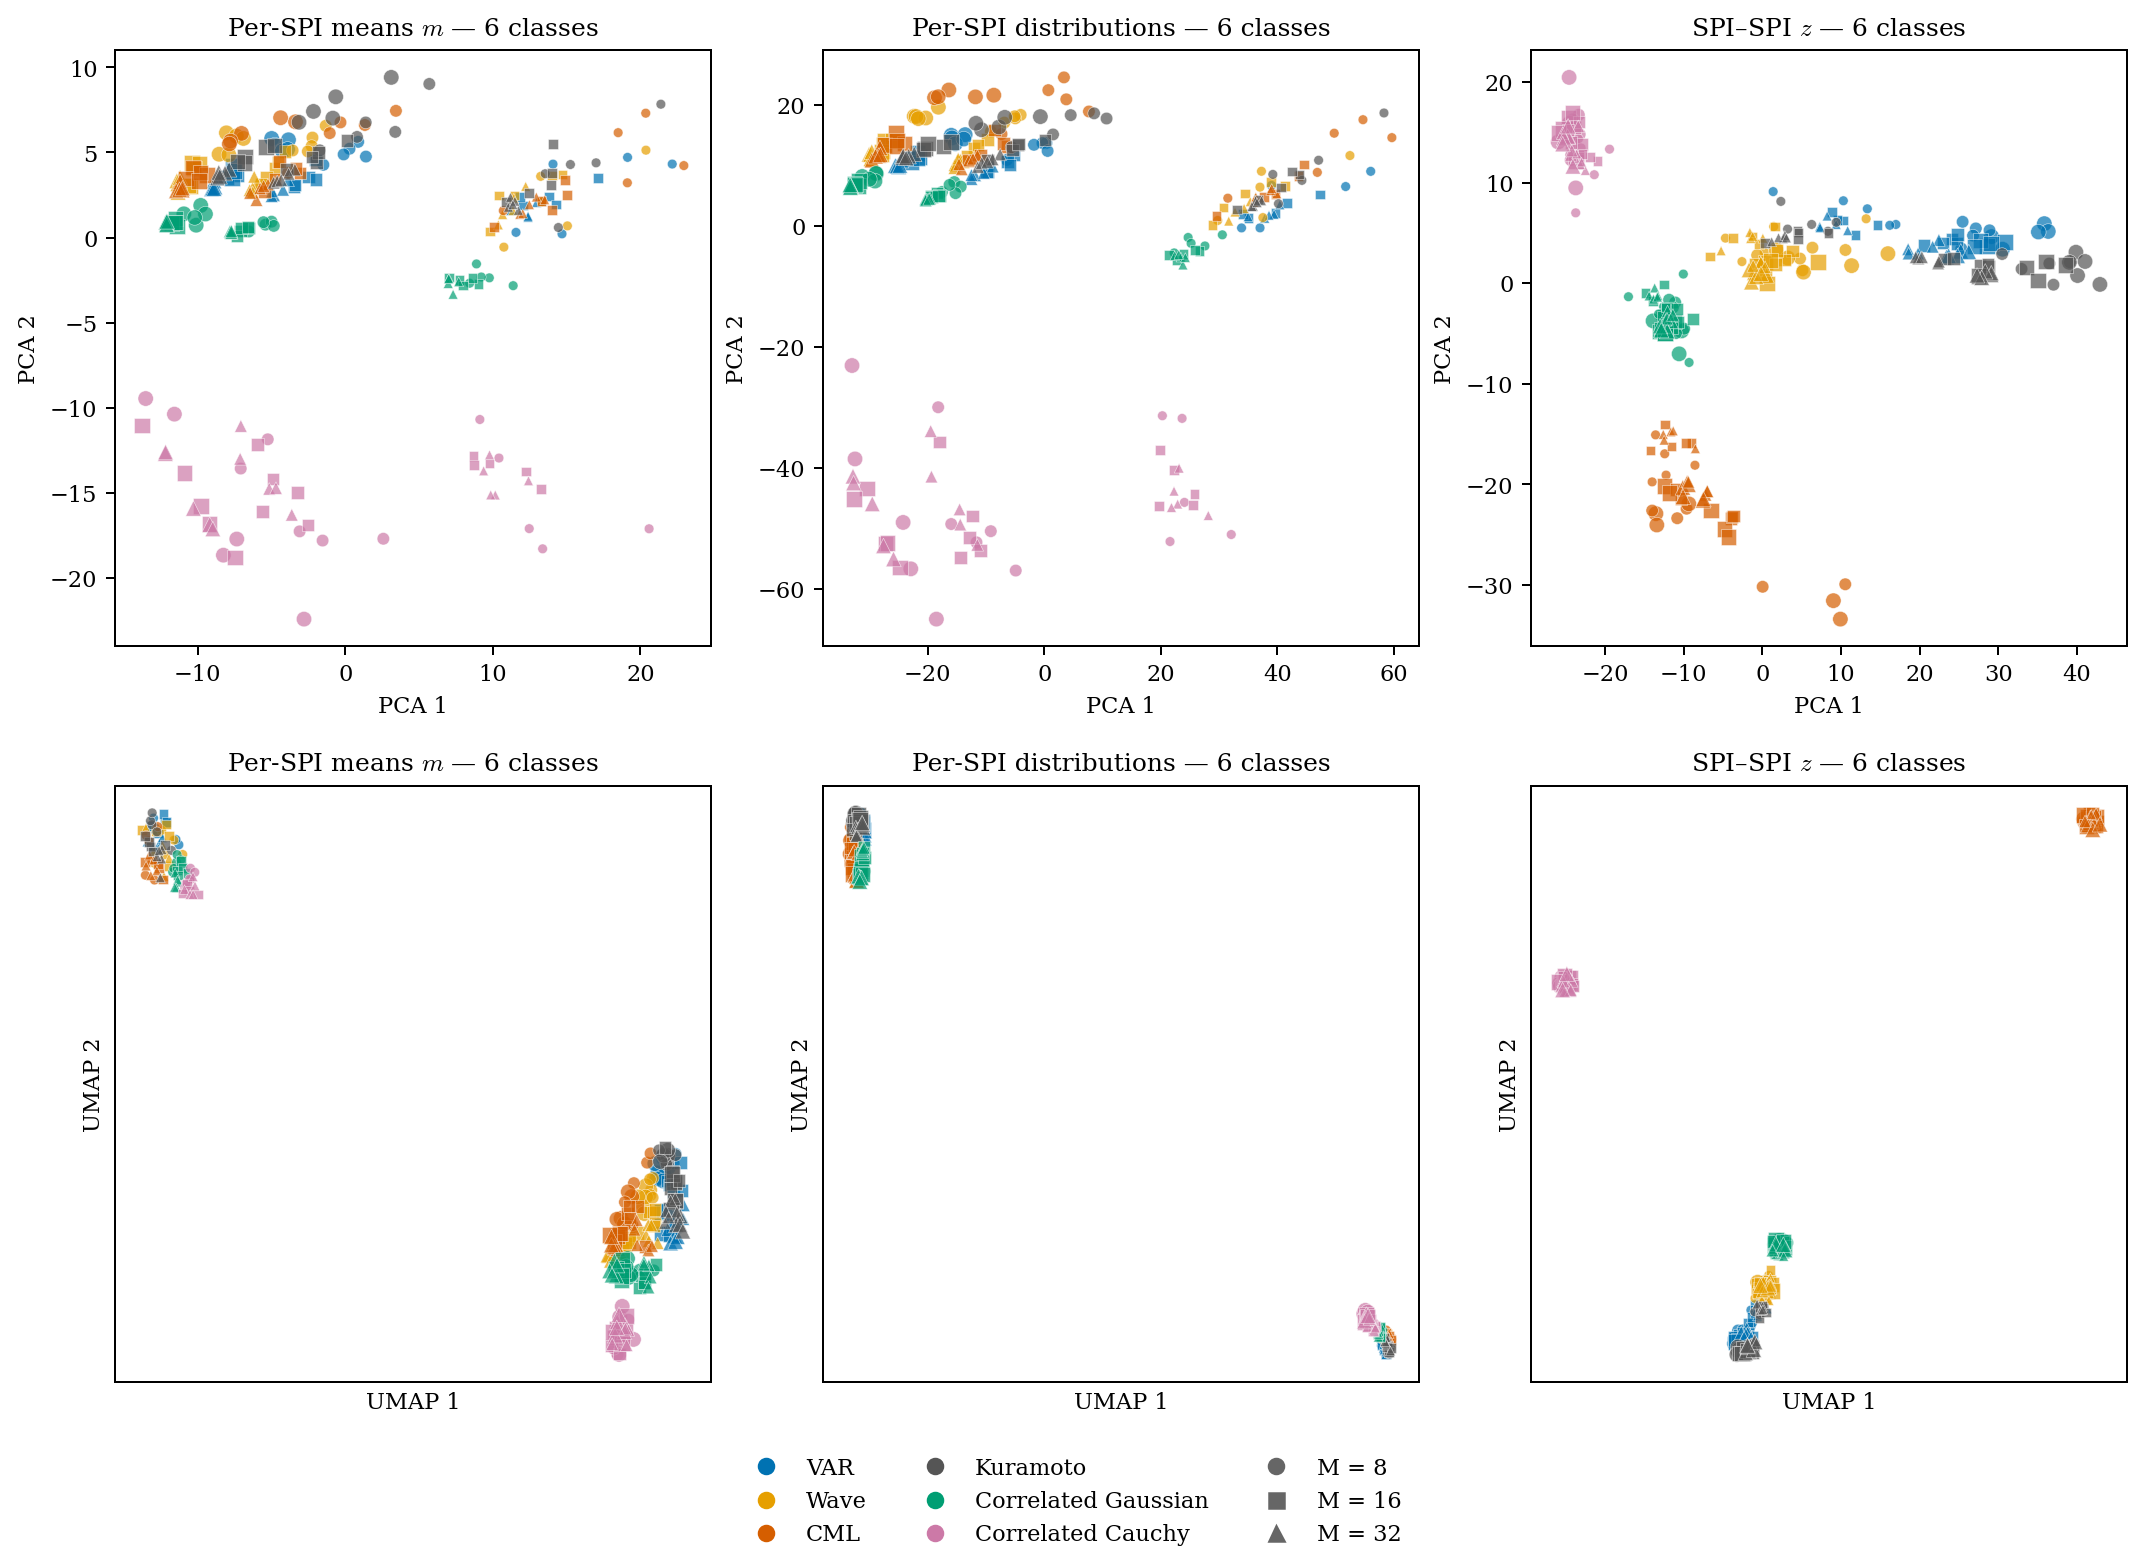

method       b  distribution   mean  z_complete
M  T                                           
8  100   0.167         0.967  0.933         1.0
   500   0.167         1.000  1.000         1.0
   1000  0.167         1.000  0.967         1.0
16 100   0.167         1.000  1.000         1.0
   500   0.167         1.000  1.000         1.0
   1000  0.167         1.000  0.967         1.0
32 100   0.167         1.000  1.000         1.0
   500   0.167         1.000  1.000         1.0
   1000  0.167         1.000  1.000         1.0

In [3]:
display(Image(filename=str(OUT/'figures/baseline-hierarchy.png')))
f=pd.read_csv(OUT/'cell-metrics.csv')
display(f[f.method.isin(['b','mean','distribution','z_complete'])].pivot(index=['M','T'],columns='method',values='BA').round(3))

Independent noise controls are projected into the same matched-data PCA spaces below, without influencing the fit. Crosses and plus signs denote independent Gaussian and Cauchy controls. These controls help reveal geometry associated with channel distributions or estimator behavior even without population cross-channel dependence; they are excluded from the six-class accuracy calculation. The accompanying table reports selected-feature missingness, filled using medians from the matched observations. If a true MPI is constant across channel pairs, its population meta-correlation is undefined. Finite-sample fluctuations can nevertheless vary together across estimators and produce structured numerical z. Consequently, a noise-family signature alone is not evidence of a corresponding population interaction mechanism.

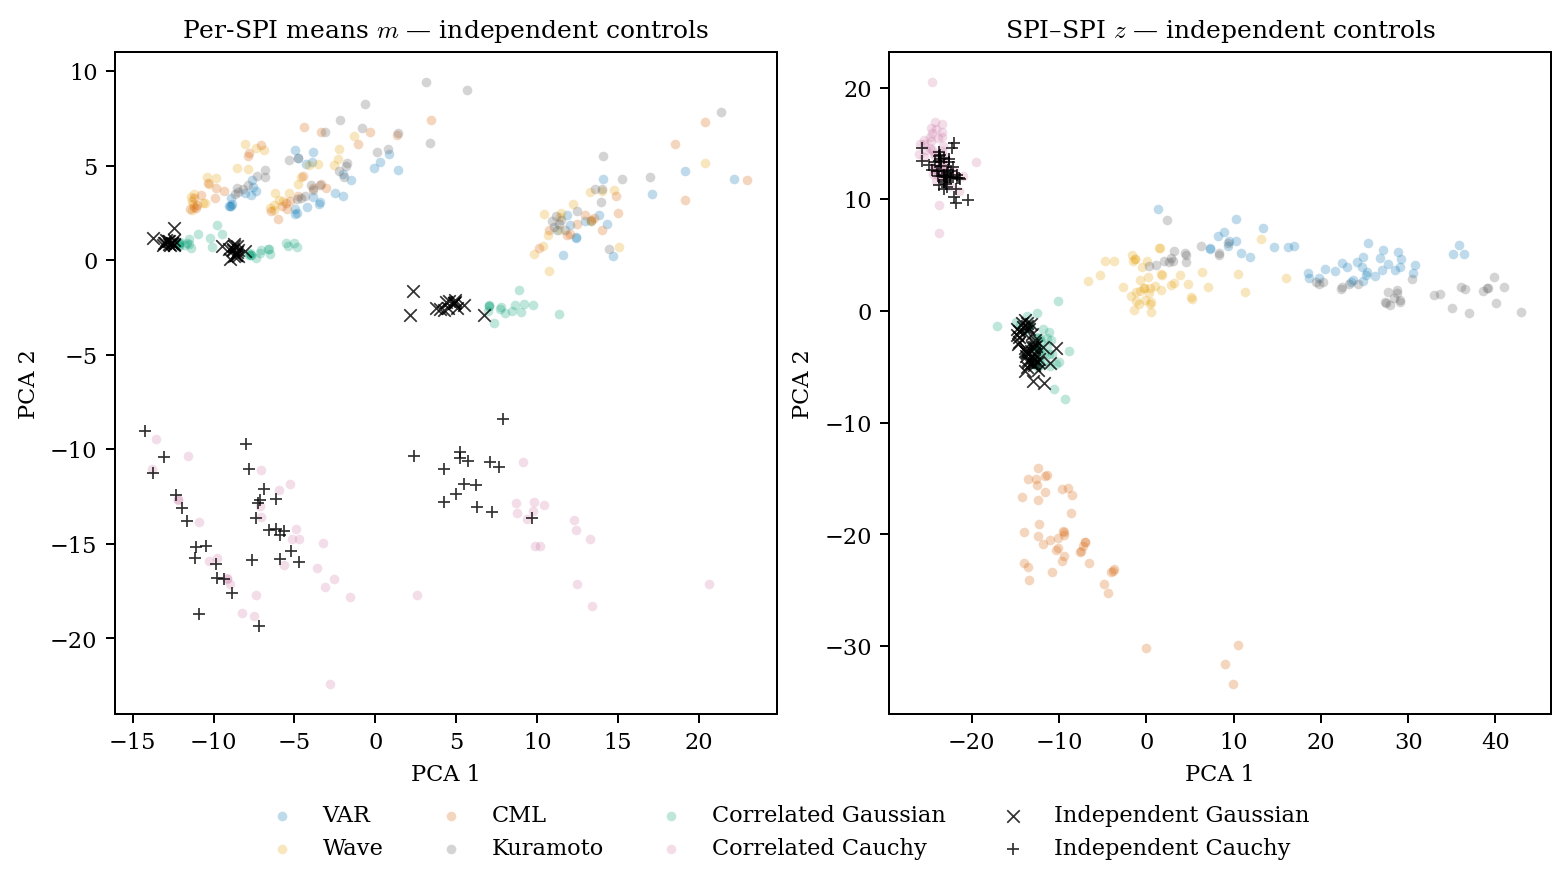

mean    max
method label                              
mean   Independent Cauchy    0.0000  0.000
       Independent Gaussian  0.0000  0.000
z      Independent Cauchy    0.0292  0.032
       Independent Gaussian  0.0271  0.032

features        test_missing_fraction     
                         min    max                   min  max
method                                                        
b                          1      1                   0.0  0.0
distribution            1886   1890                   0.0  0.0
mean                     265    265                   0.0  0.0
mean_complete            265    265                   0.0  0.0
pearson_two                2      2                   0.0  0.0
z                      29182  29182                   0.0  0.0
z_complete             29182  29182                   0.0  0.0
z_shuffled_complete    31375  31375                   0.0  0.0
z_standard             29182  29182                   0.0  0.0
z_validity              8807   8811                   0.0  0.0

In [4]:
display(Image(filename=str(OUT/'figures/independent-controls.png')))
display(pd.read_csv(OUT/'control-projection-validity.csv').groupby(['method','label']).missing_fraction.agg(['mean','max']).round(4))
display(pd.read_csv(OUT/'diagnostics.csv').groupby('method')[['features','test_missing_fraction']].agg(['min','max']).round(4))

## What this can establish

Weak $b$ with successful $z$ demonstrates information beyond matched scalar covariance summaries. The scalar baseline is deliberately deprived of class information: its near-chance result validates the control, rather than independently establishing general superiority of SPI–SPI. It does not prove that all marginal statistics are blind to character or that $z$ uniquely accesses it. Any strong MPI-mean result must be credited. Scalar matching also leaves temporal persistence, channel distributions, topology and estimator effects available; a class separation does not identify which one drives the geometry. In particular, the Gaussian and Cauchy shared-input constructions are both linear mixtures: distinguishing them does not establish nonlinear coupling. The method is invariant to positive affine changes of individual SPI profiles, not arbitrary generator-strength changes or observational-size changes.

Size-dependent targets do not give class information in this balanced design, but may contribute to size structure in the embedding. The five parent realizations, engineered normalization and exploratory model comparison limit generalization. The single-size confirmation and earlier failed all-proof, band-swap and Gaussian-factor experiments remain intact.

Frozen protocol and source bindings: `configs/analysis/pearson-size-matched-261004.yaml` and `-bindings.yaml`; run provenance: `results/representation/pearson-size-matched-261004/execution.json`. The raw archive, parent archive, ordered SPI catalogue and serial estimator RNG are audited before interpretation. All 289 SPIs in the p90 subset are attempted; no larger SPI catalogue is run. Train-fold validity selection determines the numerical features actually used.